In [124]:
import pyodbc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [125]:
conn_str = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=172.16.11.34;"
    "DATABASE=LogiProDev;"
    "UID=quentin;"
    "PWD={Barbidur1;SQL}"
)

conn = pyodbc.connect(conn_str)
cursor = conn.cursor()

requete_portails = """
SELECT 
    lep.offre_id,
    lep.langue_id,
    o.groupe_id,
    lep.portail_id,
    lep.nb_occurrences,
    lep.lep_loyer_moyen,
    lep.lep_surface_totale,
    CASE 
        WHEN t.offre_id IS NOT NULL THEN 1
        ELSE 0
    END AS has_transaction
FROM (
    SELECT 
        offre_id,
        portail_id,
        MIN(langue_id) AS langue_id,
        COUNT(DISTINCT CONVERT(date, lep_date)) AS nb_occurrences,
        MIN(lep_loyer_moyen) AS lep_loyer_moyen,
        MIN(lep_surface_total) AS lep_surface_totale,
        MIN(site_internet_id) AS site_internet_id
    FROM t_log_export_passerelle
    WHERE langue_id = 1 
      AND portail_id IS NOT NULL 
      AND portail_id NOT IN (31, 40)
    GROUP BY
        offre_id,
        portail_id
) AS lep
LEFT JOIN t_offre o
    ON o.offre_id = lep.offre_id
INNER JOIN t_groupe g
    ON g.groupe_id = o.groupe_id
    AND g.gro_actif = 1
    AND g.groupe_id NOT IN (0, 2, 147, 156, 165, 179, 1000)
LEFT JOIN (
    SELECT DISTINCT offre_id
    FROM t_transaction
) AS t
    ON t.offre_id = lep.offre_id
"""

requete_groupes_actifs = """ 
select 
    groupe_id 
from 
    t_groupe
where 
    gro_actif = 1
    and groupe_id != 0
    and groupe_id != 2
    and groupe_id != 179
    and groupe_id != 1000
    and groupe_id != 165
    and groupe_id != 147
    and groupe_id != 156
"""

data_portails = pd.read_sql_query(requete_portails, conn)
data_portails = data_portails[data_portails["offre_id"] > 0]

groupes_actifs = pd.read_sql_query(requete_groupes_actifs, conn)

data_portails = data_portails[data_portails["portail_id"] != 31]
data_portails = data_portails[data_portails["portail_id"] != 40]
data_portails = data_portails[data_portails["langue_id"] == 1]
data_portails = data_portails.drop(columns=["langue_id"])
data_portails = data_portails[data_portails["groupe_id"] != 0]
data_portails = data_portails[data_portails["groupe_id"] != 2]
data_portails = data_portails[data_portails["groupe_id"] != 179]
data_portails = data_portails[data_portails["groupe_id"] != 1000]
data_portails = data_portails[data_portails["groupe_id"] != 165]
data_portails = data_portails[data_portails["groupe_id"] != 147]
data_portails = data_portails[data_portails["groupe_id"] != 156]

conn.commit()
conn.close()

print(data_portails.head())

C:\Users\quent\AppData\Local\Temp\ipykernel_16672\853510912.py:71: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  data_portails = pd.read_sql_query(requete_portails, conn)


   offre_id  groupe_id  portail_id  nb_occurrences  lep_loyer_moyen  \
0   1391311        164          43              56       254.000000   
1   1411766         38          21              53        10.073334   
2   1428630         54          43               8         0.000000   
3   1319496         86          21              21        19.477911   
4   1368765         38          21              55        55.555557   

   lep_surface_totale  has_transaction  
0                70.0                0  
1               412.0                0  
2               102.0                0  
3               415.0                0  
4                15.0                0  


C:\Users\quent\AppData\Local\Temp\ipykernel_16672\853510912.py:74: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  groupes_actifs = pd.read_sql_query(requete_groupes_actifs, conn)


In [126]:
# On réduit la taille du tableau 

# Arrondi
data_portails[["lep_loyer_moyen", "lep_surface_totale"]] = (
    data_portails[["lep_loyer_moyen", "lep_surface_totale"]].round(2)
)

# Downcast floats
for col in data_portails.select_dtypes(include=["float"]).columns:
    data_portails[col] = pd.to_numeric(data_portails[col], downcast="float")

# Downcast ints
for col in data_portails.select_dtypes(include=["int"]).columns:
    data_portails[col] = pd.to_numeric(data_portails[col], downcast="integer")

# Category
for col in ["portail_id", "groupe_id"] :
    data_portails[col] = data_portails[col].astype("category")

On va raisonner depuis le début de la collecte de données en septembre pour avoir un maximum de transactions, si on se limite dans nos statistiques aux observations du dernier mois on aura trop de biais dans l'estimation de l'efficacité des portails au vu de la rareté des transactions

**On commence par des statistiques en prenant les groupes individuellement**

In [127]:
print(f'Au total, il y a {data_portails["portail_id"].nunique()} portails différents')

Au total, il y a 28 portails différents


In [128]:
# On découpe les données par groupes
# (pourquoi pas faire aussi des statistiques agrégées plus tard)

groupes_ids = groupes_actifs["groupe_id"].tolist()

data_portails_par_groupe = {}

for id in groupes_ids :
    data_portails_par_groupe[id] = data_portails[data_portails["groupe_id"] == id].copy()

Première statistique : nombre de portails utilisés

[2 4 0 3 9 6 5 1 7]
   groupe_id  nb_portails
0          5            2
1          7            2
2         13            4
3         14            4
4         18            0


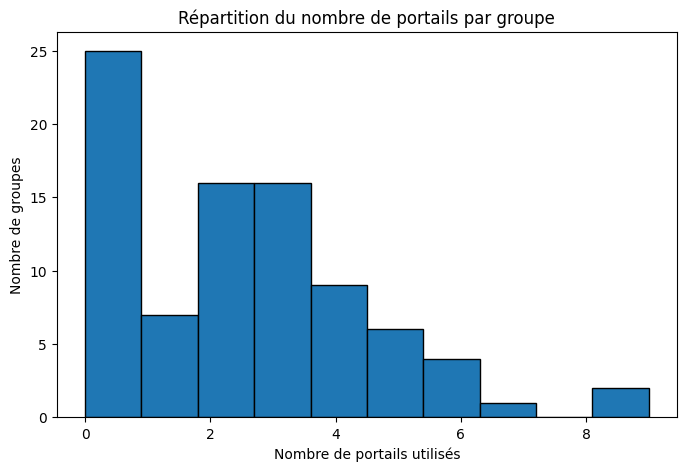

In [129]:
# On initialise le dataframe des groupes et nombre de portails utilisés au cours des 3 derniers mois
nombre_de_portails_utilises = pd.DataFrame({"groupe_id" : groupes_actifs["groupe_id"]})

liste_nombres = []
for id in groupes_actifs["groupe_id"] :
    nb_portails = data_portails_par_groupe[id]["portail_id"].nunique()
    liste_nombres.append(nb_portails)

nombre_de_portails_utilises["nb_portails"] = liste_nombres

print(nombre_de_portails_utilises["nb_portails"].unique())
print(nombre_de_portails_utilises.head())

plt.figure(figsize=(8, 5))
plt.hist(nombre_de_portails_utilises["nb_portails"], bins=10, edgecolor="black")

plt.xlabel("Nombre de portails utilisés")
plt.ylabel("Nombre de groupes")
plt.title("Répartition du nombre de portails par groupe")

plt.show()

In [130]:
conn_str = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=172.16.11.34;"
    "DATABASE=Superset;"
    "UID=quentin;"
    "PWD={Barbidur1;SQL}"
)

conn = pyodbc.connect(conn_str)
cursor = conn.cursor()

cursor.execute("TRUNCATE TABLE nb_portails_par_groupe")

sql_insert = """
INSERT INTO db_owner.nb_portails_par_groupe (groupe_id, nb_portails)
VALUES (?, ?)
"""

data = list(
    nombre_de_portails_utilises[["groupe_id", "nb_portails"]]
    .itertuples(index=False, name=None)
)

cursor.fast_executemany = True
cursor.executemany(sql_insert, data)
conn.commit()

Première statistique : combien d'offres ont été publiées sur chacun des portails au cours des derniers mois

C:\Users\quent\AppData\Local\Temp\ipykernel_16672\3534004812.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["groupe_id", "portail_id"])["offre_id"]


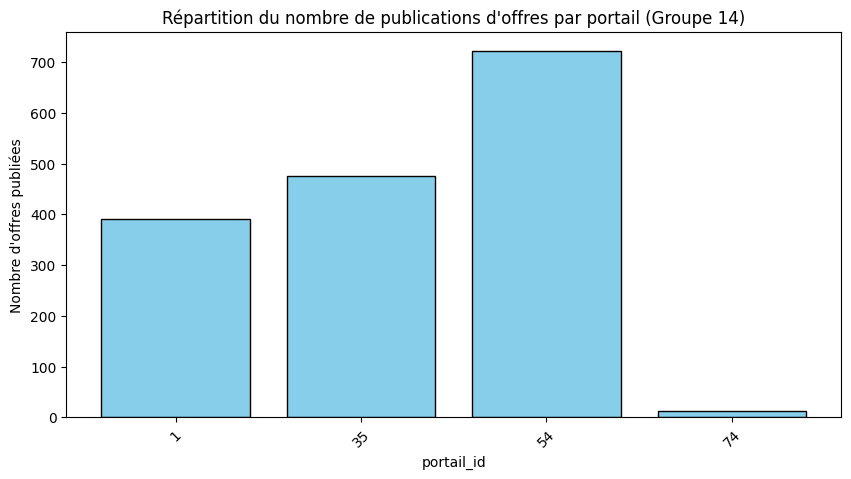

In [131]:
offres_par_portail = (
    data_portails
    .groupby(["groupe_id", "portail_id"])["offre_id"]
    .nunique()
    .reset_index()
    .rename(columns={"offre_id": "nb_offres"})
)

offres_par_portail = offres_par_portail[offres_par_portail["nb_offres"] > 0]

offres_par_portail.head(20)

plt.figure(figsize=(10, 5))
plt.bar(
    offres_par_portail[offres_par_portail["groupe_id"] == 13]["portail_id"].astype(str),  # on transforme en str pour que les barres soient espacées uniformément
    offres_par_portail[offres_par_portail["groupe_id"] == 13]["nb_offres"],
    color="skyblue",
    edgecolor="black"
)

plt.xlabel("portail_id")
plt.ylabel("Nombre d'offres publiées")
plt.title("Répartition du nombre de publications d'offres par portail (Groupe 14)")

plt.xticks(rotation=45)  # rotation si les IDs sont nombreux
plt.show()

In [132]:
cursor.execute("TRUNCATE TABLE db_owner.nb_offres_par_portail_par_groupe")

sql_insert = """
INSERT INTO db_owner.nb_offres_par_portail_par_groupe (groupe_id, portail_id, nb_offres)
VALUES (?, ?, ?)
"""

data = list(
    offres_par_portail[["groupe_id", "portail_id", "nb_offres"]]
    .itertuples(index=False, name=None)
)

cursor.fast_executemany = True
cursor.executemany(sql_insert, data)
conn.commit()

Deuxième statistique : distribution du nombre de jours de publication pour chaque offre sur chacun des portails

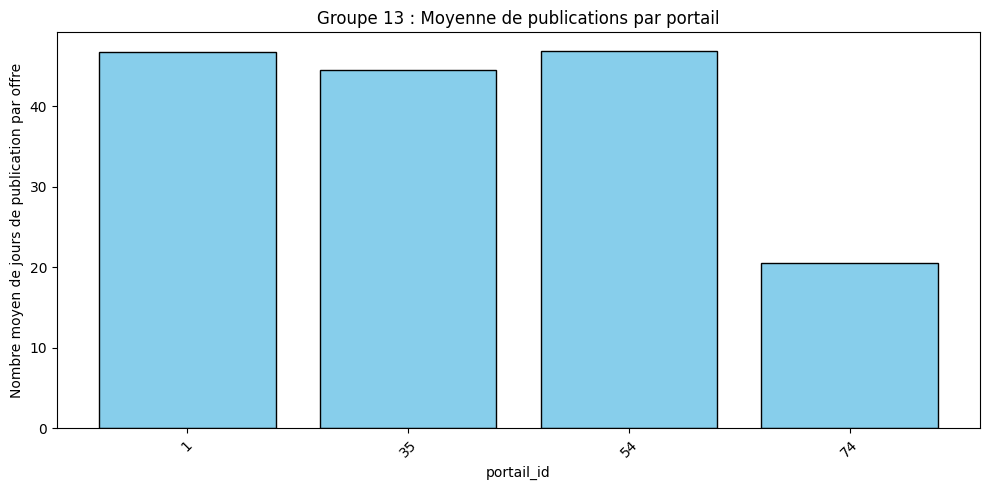

In [133]:
# Nombre de jours de publication par offre
# (nb_occurrences est déjà le nombre de jours)
df_jours_par_offre = data_portails[[
    "groupe_id",
    "portail_id",
    "offre_id",
    "nb_occurrences"
]].rename(columns={"nb_occurrences": "nb_jours"})

# On garde uniquement les publications réelles
df_jours_par_offre = df_jours_par_offre[df_jours_par_offre["nb_jours"] > 0]

# Moyenne du nombre de jours de publication par portail et par groupe
df_moyenne_par_portail = (
    df_jours_par_offre
    .groupby(["groupe_id", "portail_id"], observed=True)["nb_jours"]
    .mean()
    .reset_index(name="moyenne_nb_jours_par_offre")
)

# Histogramme / bar chart pour le groupe 38
df_g13 = df_moyenne_par_portail[df_moyenne_par_portail["groupe_id"] == 13]

plt.figure(figsize=(10,5))
plt.bar(
    df_g13["portail_id"].astype(str),   # barres collées
    df_g13["moyenne_nb_jours_par_offre"],
    color="skyblue",
    edgecolor="black"
)

plt.xlabel("portail_id")
plt.ylabel("Nombre moyen de jours de publication par offre")
plt.title("Groupe 13 : Moyenne de publications par portail")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [134]:
cursor.execute("TRUNCATE TABLE db_owner.nb_moyenne_jours_par_offre_par_portail")

sql_insert = """
INSERT INTO db_owner.nb_moyenne_jours_par_offre_par_portail (groupe_id, portail_id, moyenne_nb_jours_par_offre)
VALUES (?, ?, ?)
"""

data = list(
    df_moyenne_par_portail[["groupe_id", "portail_id", "moyenne_nb_jours_par_offre"]]
    .itertuples(index=False, name=None)
)

cursor.fast_executemany = True
cursor.executemany(sql_insert, data)
conn.commit()

Troisième statistique : distribution du nombre total de portails sur lesquels ont été publiées les offres

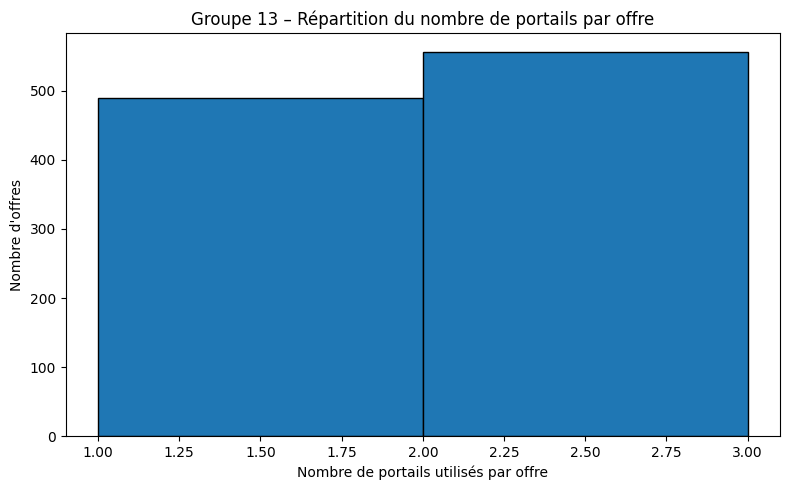

In [135]:
df_nb_portails_par_offre = (
    data_portails
    .groupby(["groupe_id", "offre_id"], observed=True)["portail_id"]
    .nunique()
    .reset_index(name="nb_portails")
)

df_g13 = df_nb_portails_par_offre[
    df_nb_portails_par_offre["groupe_id"] == 13
]

plt.figure(figsize=(8,5))
plt.hist(
    df_g13["nb_portails"],
    bins=range(1, df_g13["nb_portails"].max() + 2),
    edgecolor="black"
)

plt.xlabel("Nombre de portails utilisés par offre")
plt.ylabel("Nombre d'offres")
plt.title("Groupe 13 – Répartition du nombre de portails par offre")
plt.tight_layout()
plt.show()

In [136]:
cursor.execute("TRUNCATE TABLE db_owner.nb_portails_par_offre")

sql_insert = """
INSERT INTO db_owner.nb_portails_par_offre (groupe_id, offre_id, nb_portails)
VALUES (?, ?, ?)
"""

data = list(
    df_nb_portails_par_offre[["groupe_id", "offre_id", "nb_portails"]]
    .itertuples(index=False, name=None)
)

cursor.fast_executemany = True
cursor.executemany(sql_insert, data)

conn.commit()

Quatrième statistique : nombre de ventes issues de chaque portail : manque info du portail d'où est issue la transaction ! 
On se limite aux transactions des offres qui ont été publiées sur un seul portail ? 

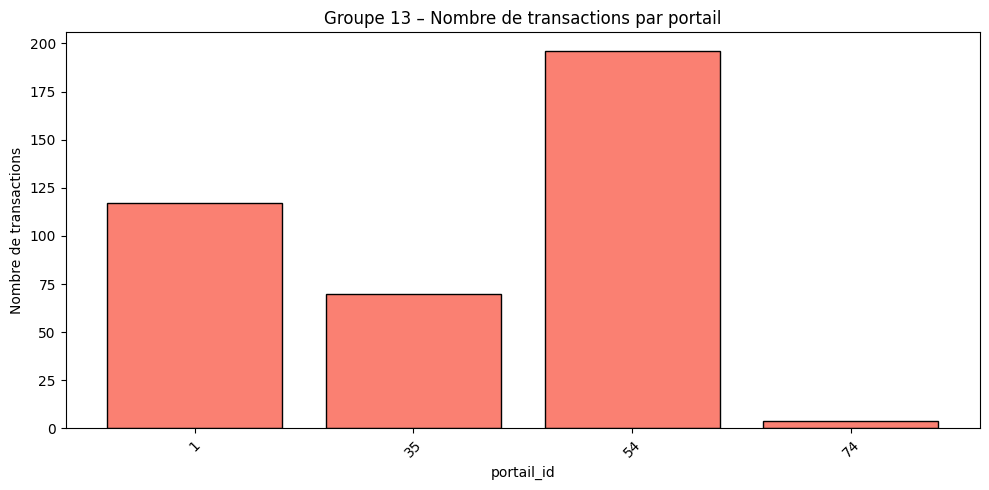

In [137]:
# ATTENTION, POUR CETTE STATISTIQUE ON NE CONSERVE QUE LES OFFRES QUI ONT DONNE LIEU A UNE TRANSACTION !!
df_transactions = data_portails[data_portails["has_transaction"] == 1]

df_ventes_par_portail = (
    df_transactions
    .groupby(["groupe_id", "portail_id"], observed=True)["offre_id"]
    .nunique()
    .reset_index(name="nb_ventes")
)

df_g13 = df_ventes_par_portail[
    df_ventes_par_portail["groupe_id"] == 13
]

plt.figure(figsize=(10,5))
plt.bar(
    df_g13["portail_id"].astype(str),
    df_g13["nb_ventes"],
    color="salmon",
    edgecolor="black"
)

plt.xlabel("portail_id")
plt.ylabel("Nombre de transactions")
plt.title("Groupe 13 – Nombre de transactions par portail")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [138]:
cursor.execute("TRUNCATE TABLE db_owner.nb_ventes_par_portail")

sql_insert = """
INSERT INTO db_owner.nb_ventes_par_portail (groupe_id, portail_id, nb_ventes)
VALUES (?, ?, ?)
"""

data = list(
    df_ventes_par_portail[["groupe_id", "portail_id", "nb_ventes"]]
    .itertuples(index=False, name=None)
)

cursor.fast_executemany = True
cursor.executemany(sql_insert, data)
conn.commit()

Cinquième statistique : on compare le nombre total de publications qui ont été faites par portail avec le nombre de transactions

In [139]:
# Calcul du nombre total de jours de publication par portail
df_total_jours = pd.merge(
    df_moyenne_par_portail,
    offres_par_portail,
    on=["groupe_id", "portail_id"],
    how="left"
)

df_total_jours["total_jours"] = df_total_jours["moyenne_nb_jours_par_offre"] * df_total_jours["nb_offres"]

# On fusionne avec le nombre de ventes
ratio_nb_transacs_nb_ventes = pd.merge(
    df_ventes_par_portail,
    df_total_jours[["groupe_id", "portail_id", "total_jours"]],
    on=["groupe_id", "portail_id"],
    how="left"
)

# Calcul du ratio
ratio_nb_transacs_nb_ventes["ratio_ventes_par_jour"] = ratio_nb_transacs_nb_ventes["nb_ventes"] / ratio_nb_transacs_nb_ventes["total_jours"]

ratio_nb_transacs_nb_ventes.head()

,groupe_id,portail_id,nb_ventes,total_jours,ratio_ventes_par_jour
0,13,1,117,18300.0,0.006393
1,13,35,70,21185.0,0.003304
2,13,54,196,33874.0,0.005786
3,13,74,4,246.0,0.016260
4,14,21,46,7963.0,0.005777


In [ ]:
cursor.execute("TRUNCATE TABLE db_owner.ratio_ventes_par_jour_par_portail")

sql_insert = """
INSERT INTO db_owner.ratio_ventes_par_jour_par_portail 
(groupe_id, portail_id, nb_ventes, total_jours, ratio_ventes_par_jour)
VALUES (?, ?, ?, ?, ?)
"""

data = list(
    ratio_nb_transacs_nb_ventes[["groupe_id", "portail_id", "nb_ventes", "total_jours", "ratio_ventes_par_jour"]]
    .itertuples(index=False, name=None)
)

cursor.fast_executemany = True
cursor.executemany(sql_insert, data)
conn.commit()

: 

Cinquième statistique : régression du nombre de jours inscrits sur un portail avant transaction sur la surface totale de l'offre (modèle de censure pour aussi prendre en compte les offres qui n'ont pour l'instant pas donné lieu à une transaction ?)

Sixième statistique : régression du nombre de jours inscrits sur un portail avant transaction sur le prix de l'offre

Septième statistique : régression du nombre de jours inscrits sur un portail avant transaction sur le nombre de lots de l'offre

Huitième statistique : 

Statistiques agrégées

In [92]:
# Copier ton DataFrame pour ne pas modifier l'original
df = data_portails.copy()

# Nombre de portails différents par offre
df["nb_portails"] = df.groupby("offre_id")["portail_id"].transform("nunique")

# Nombre total d'occurrences de l'offre sur tous les portails
df["total_occurrences_offre"] = df.groupby("offre_id")["nb_occurrences"].transform("sum")

# Afficher le résultat
print(df.head())

   offre_id groupe_id portail_id  nb_occurrences  lep_loyer_moyen  \
0   1106039        14         54              57        81.480003   
1    136666        13         54              57        12.080000   
2   1418127        54         16              30         0.000000   
3   1396268       144         54             111        12.500000   
4   1397570        38         35              57         0.000000   

   lep_surface_totale  has_transaction  nb_portails  total_occurrences_offre  
0             2145.70                0            4                      227  
1              873.49                1            2                      114  
2              125.00                0            6                      179  
3              450.00                0            5                      335  
4             1334.00                0            6                      339  


In [93]:
nb_portails_par_offre = data_portails.groupby("offre_id")["portail_id"].nunique().reset_index()
nb_portails_par_offre.rename(columns={"portail_id": "nb_portails"}, inplace=True)

print(nb_portails_par_offre.tail())

       offre_id  nb_portails
40563   1435814            1
40564   1435816            1
40565   1435843            3
40566   1435845            5
40567   1435850            5


In [94]:
conn.commit()
conn.close()